In [2]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

# file_name = '/storage/1/st15719/caf_new_sum_weighted.root'
file_name = '/storage/1/st15719/caf_new_sum.2.6M_weighted.root'
PDG_BRANCH = 'rec/mc/mc.nu/mc.nu.pdg'
CVN_BRANCHES = {
	'nue': 'rec/common/common.ixn.pandora/common.ixn.pandora.nuhyp.cvn.nue',
	'numu': 'rec/common/common.ixn.pandora/common.ixn.pandora.nuhyp.cvn.numu'
}

import os

save_dir = "figures"


Loading data...
Data loaded successfully.


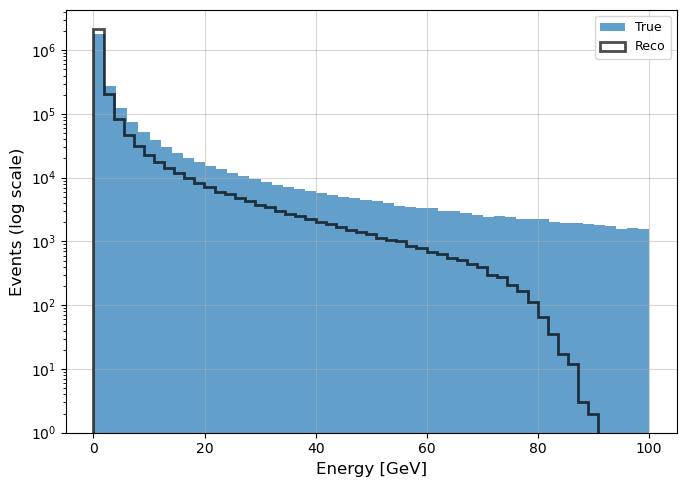

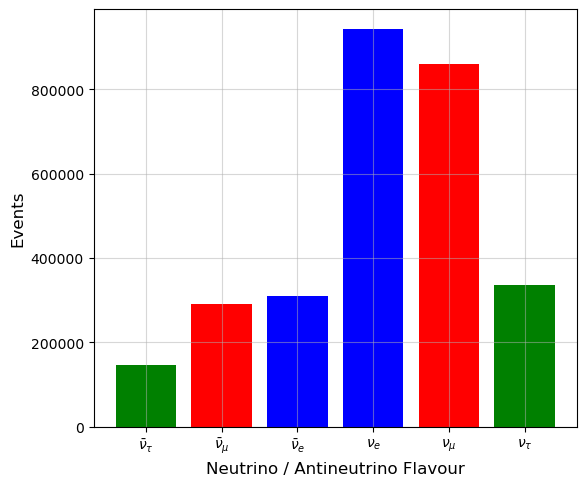

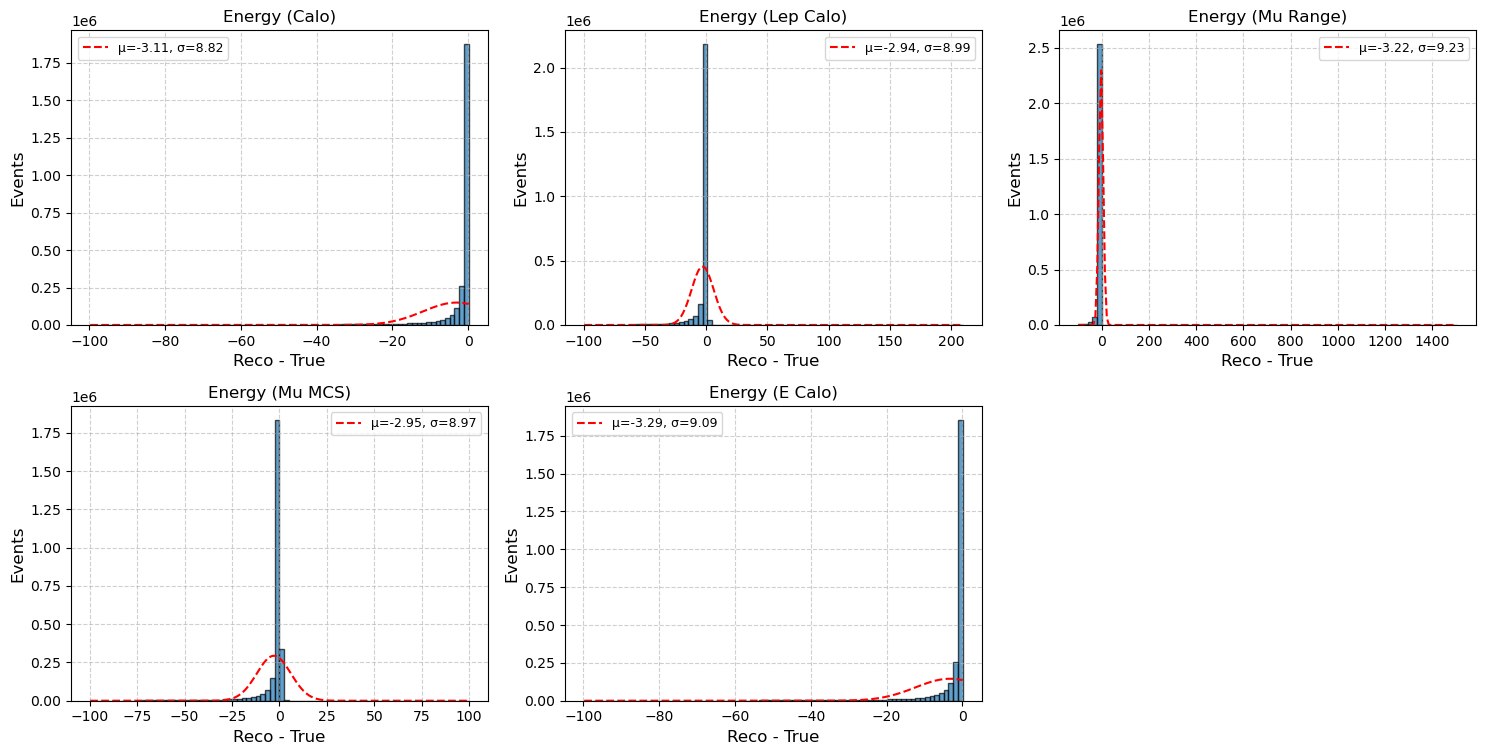

In [16]:

TRUE_RECO_PAIRS = {
	'Energy (Calo)': (
		'rec/mc/mc.nu/mc.nu.E',
		'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.calo'
	),
	'Energy (Lep Calo)': (
		'rec/mc/mc.nu/mc.nu.E',
		'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.lep_calo'
	),
	'Energy (Mu Range)': (
		'rec/mc/mc.nu/mc.nu.E',
		'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range'
	),
	'Energy (Mu MCS)': (
		'rec/mc/mc.nu/mc.nu.E',
		'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_mcs'
	),
	'Energy (E Calo)': (
		'rec/mc/mc.nu/mc.nu.E',
		'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo'
	)
}



def set_plot_style():
	plt.rcParams.update({
		"font.size": 10,
		"axes.labelsize": 11,
		"xtick.labelsize": 9,
		"ytick.labelsize": 9,
		"legend.fontsize": 9,
		"axes.titlesize": 11,
		"lines.linewidth": 1.5
	})

PDG_LABELS = {
	12: r'$\nu_e$', -12: r'$\bar{\nu}_e$',
	14: r'$\nu_\mu$', -14: r'$\bar{\nu}_\mu$',
	16: r'$\nu_\tau$', -16: r'$\bar{\nu}_\tau$'
}

def flatten_series(series):
	def flatten_cell(cell):
		if isinstance(cell, (list, np.ndarray)):
			return cell[0] if len(cell) > 0 else -999
		return cell
	return series.apply(flatten_cell)


print("Loading data...")
with uproot.open(file_name) as f:
	tree = f['cafTree']
	all_branches = list(set(sum(TRUE_RECO_PAIRS.values(), ())) | {PDG_BRANCH} | set(CVN_BRANCHES.values()))
	data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

df = pd.DataFrame({col: flatten_series(data[col]) for col in data.columns})

true_energy = df[TRUE_RECO_PAIRS['Energy (Calo)'][0]]
reco_energy = df[TRUE_RECO_PAIRS['Energy (Calo)'][1]]
valid_E = (true_energy > 0) & (reco_energy > 0)

plt.figure(figsize=(7,5))
plt.hist(true_energy[valid_E], bins=50, alpha=0.7, label='True')
plt.hist(reco_energy[valid_E], bins=50, alpha=0.7, label='Reco', edgecolor='black', histtype='step', linewidth=2)
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('Events (log scale)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "energy_comparison.pdf"), bbox_inches="tight")
plt.show()

pdg = df[PDG_BRANCH]
plt.figure(figsize=(6,5))
counts = pdg.value_counts().sort_index()
labels = [PDG_LABELS.get(int(x), str(x)) for x in counts.index]
colour_map = {
    12: 'blue', -12: 'blue',
    14: 'red', -14: 'red',
    16: 'green', -16: 'green'
}
bar_colours = [colour_map.get(int(x), 'grey') for x in counts.index]
plt.bar(labels, counts.values, color=bar_colours)
plt.xlabel('Neutrino / Antineutrino Flavour')
plt.ylabel('Events')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "pdg_counts.pdf"), bbox_inches="tight")
plt.show()

n_plots = len(TRUE_RECO_PAIRS)
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, (label, (true_b, reco_b)) in enumerate(TRUE_RECO_PAIRS.items()):
	ax = axes[i]
	true_vals = df[true_b]
	reco_vals = df[reco_b]
	valid_mask = (true_vals != -999) & (reco_vals != -999)
	diff = reco_vals[valid_mask] - true_vals[valid_mask]

	if diff.empty:
		ax.set_title(f"{label} (no valid data)")
		continue

	n, bins, _ = ax.hist(diff, bins=80, color='C0', alpha=0.7, edgecolor='black')
	ax.set_title(label)
	ax.set_xlabel('Reco - True')
	ax.set_ylabel('Events')

	try:
		mu, sigma = norm.fit(diff)
		x = np.linspace(bins[0], bins[-1], 200)
		pdf = norm.pdf(x, mu, sigma) * len(diff) * (bins[1]-bins[0])
		ax.plot(x, pdf, 'r--', label=f'μ={mu:.2f}, σ={sigma:.2f}')
		ax.legend()
	except Exception:
		pass

	ax.grid(True, linestyle='--', alpha=0.6)

for j in range(i+1, len(axes)):
	fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Loading data...
Data loaded successfully.


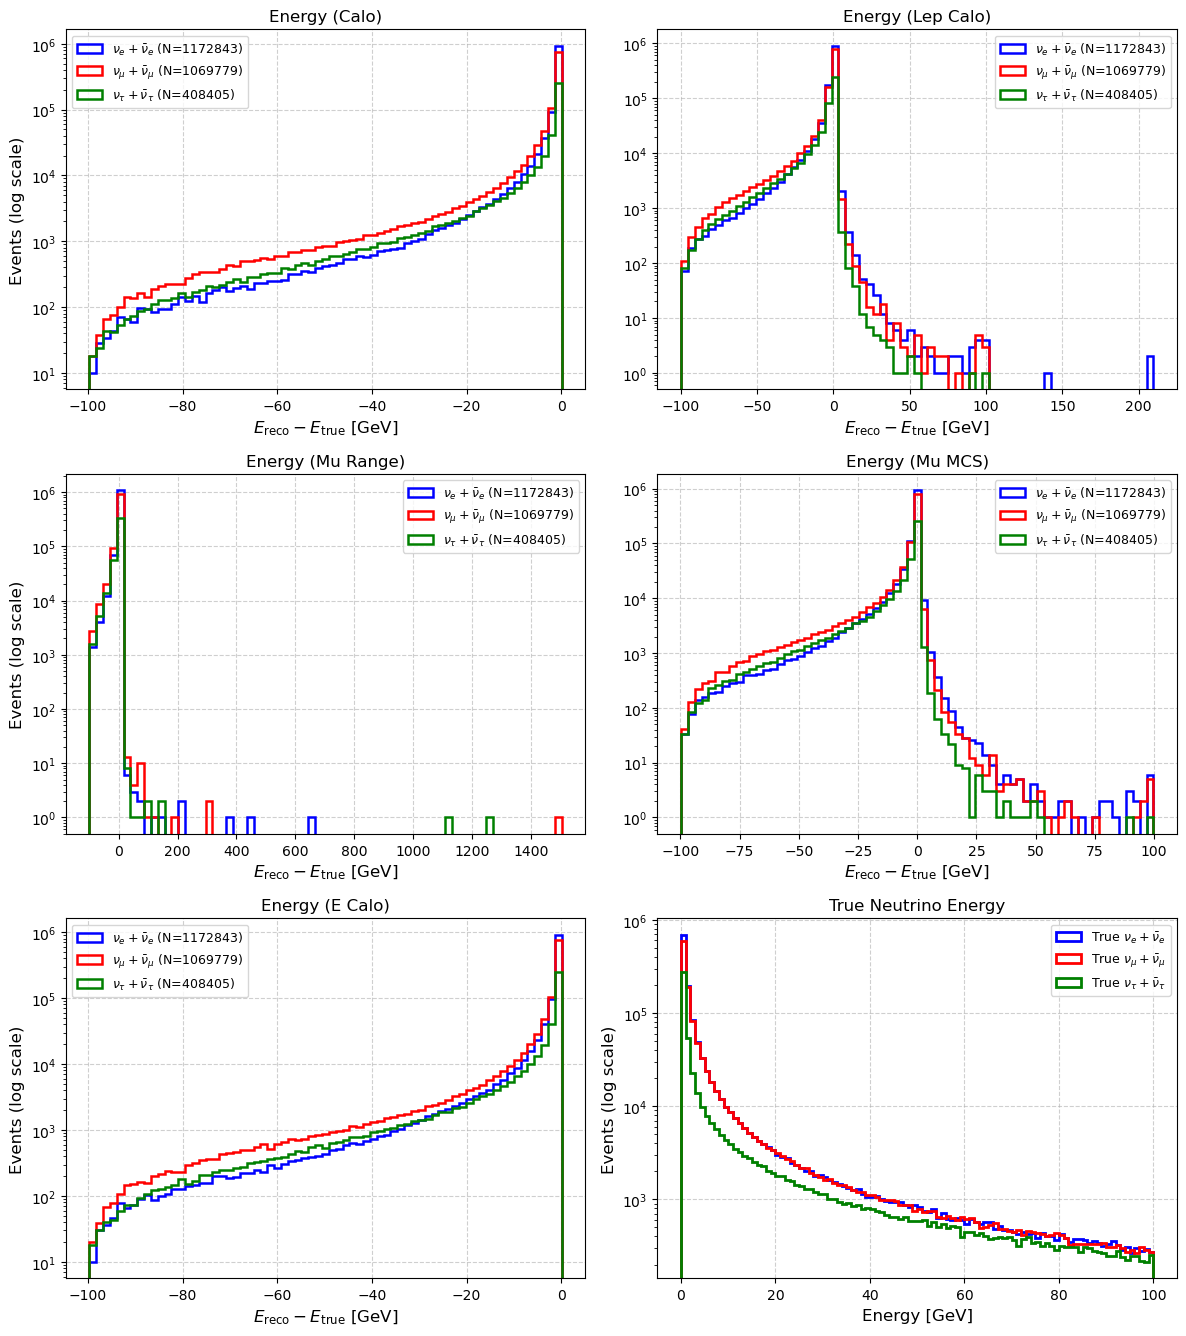

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

TRUE_E_BRANCH = 'rec/mc/mc.nu/mc.nu.E'

TRUE_RECO_PAIRS = {
    'Energy (Calo)': (
        TRUE_E_BRANCH,
        'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.calo'
    ),
    'Energy (Lep Calo)': (
        TRUE_E_BRANCH,
        'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.lep_calo'
    ),
    'Energy (Mu Range)': (
        TRUE_E_BRANCH,
        'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range'
    ),
    'Energy (Mu MCS)': (
        TRUE_E_BRANCH,
        'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_mcs'
    ),
    'Energy (E Calo)': (
        TRUE_E_BRANCH,
        'rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo'
    )
}

FLAVOUR_GROUPS = {
    r'$\nu_e + \bar{\nu}_e$': [12, -12],
    r'$\nu_\mu + \bar{\nu}_\mu$': [14, -14],
    r'$\nu_\tau + \bar{\nu}_\tau$': [16, -16]
}

# Define the standard colour scheme globally for consistency
STANDARD_COLOURS = ['blue', 'red', 'green']

def set_plot_style():
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.titlesize": 12,
        "lines.linewidth": 1.5
    })

def flatten_series(series):
    def flatten_cell(cell):
        if isinstance(cell, (list, np.ndarray)):
            return cell[0] if len(cell) > 0 else -999
        return cell
    return series.apply(flatten_cell)

set_plot_style()

print("Loading data...")
with uproot.open(file_name) as f:
    tree = f['cafTree']
    all_branches = list(set(sum(TRUE_RECO_PAIRS.values(), ())) | {PDG_BRANCH, TRUE_E_BRANCH})
    data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

df = pd.DataFrame({col: flatten_series(data[col]) for col in data.columns})
pdg = df[PDG_BRANCH]

n_plots_total = len(TRUE_RECO_PAIRS) + 1
n_cols = 2
n_rows = math.ceil(n_plots_total / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, (label, (true_b, reco_b)) in enumerate(TRUE_RECO_PAIRS.items()):
    ax = axes[i]

    true_vals = df[true_b]
    reco_vals = df[reco_b]

    valid_mask = (
        (true_vals != -999) &
        (reco_vals != -999) &
        (true_vals > 0) &
        (reco_vals > 0)
    )

    if valid_mask.sum() == 0:
        ax.set_title(f"{label} (no valid data)")
        ax.set_xlabel(r'$E_{\mathrm{reco}} - E_{\mathrm{true}}$ [GeV]')
        if i % n_cols == 0:
            ax.set_ylabel('Normalised events')
        continue

    diff_all = (reco_vals[valid_mask] - true_vals[valid_mask]).to_numpy()

    xmin = np.min(diff_all)
    xmax = np.max(diff_all)
    bins = np.linspace(xmin, xmax, 70)

    # Zip the colours here for the energy resolution plots
    for (flavour_label, pdgs), colour in zip(FLAVOUR_GROUPS.items(), STANDARD_COLOURS):
        flavour_mask = valid_mask & pdg.isin(pdgs)
        diff = (reco_vals[flavour_mask] - true_vals[flavour_mask]).to_numpy()

        if len(diff) == 0:
            continue

        ax.hist(
            diff,
            bins=bins,
            histtype='step',
            linewidth=1.8,
            density=False,
            label=f'{flavour_label} (N={len(diff)})',
            color=colour
        )

    ax.set_title(label)
    ax.set_xlabel(r'$E_{\mathrm{reco}} - E_{\mathrm{true}}$ [GeV]')
    
    if i % n_cols == 0:
        ax.set_ylabel('Events (log scale)')
        
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

ax_true = axes[len(TRUE_RECO_PAIRS)]
true_e_mask = (df[TRUE_E_BRANCH] != -999) & (df[PDG_BRANCH] != -999) & (df[TRUE_E_BRANCH] > 0)

bins_true = 100
plot_range_true = (0, 100) # GeV

for (flavour_label, pdgs), colour in zip(FLAVOUR_GROUPS.items(), STANDARD_COLOURS):
    flavour_mask = df[PDG_BRANCH].isin(pdgs) & true_e_mask
    energies = df.loc[flavour_mask, TRUE_E_BRANCH]
    
    if len(energies) > 0:
        ax_true.hist(
            energies, 
            bins=bins_true, 
            range=plot_range_true, 
            label=f'True {flavour_label}', 
            histtype='step', 
            linewidth=2, 
            color=colour
        )

ax_true.set_title("True Neutrino Energy")
ax_true.set_xlabel('Energy [GeV]')
ax_true.set_ylabel('Events (log scale)') 
ax_true.set_yscale('log')
ax_true.legend()
ax_true.grid(True, linestyle='--', alpha=0.6)

for j in range(len(TRUE_RECO_PAIRS) + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(
    os.path.join(save_dir, "energy_resolution_and_true_combined.pdf"),
    bbox_inches="tight"
)
plt.show()

Loading data...
Data loaded successfully.
Data flattened.
Generating CVN separation plots...


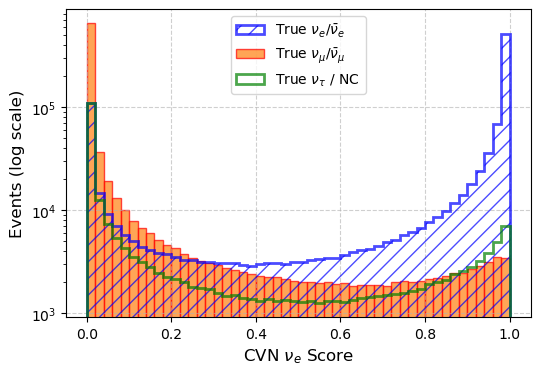

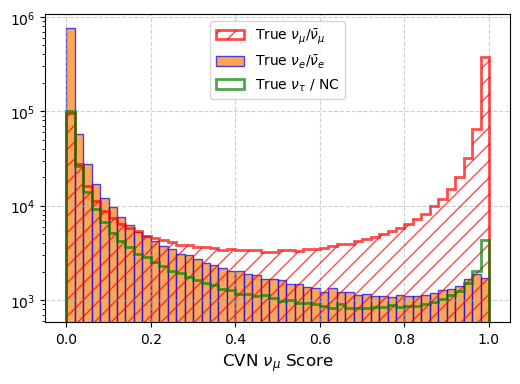

In [18]:

PDG_LABELS = {
    12: r'$\nu_e$', -12: r'$\bar{\nu}_e$',
    14: r'$\nu_\mu$', -14: r'$\bar{\nu}_\mu$',
    16: r'$\nu_\tau$', -16: r'$\bar{\nu}_\tau$'
}

#CVN Score by True Neutrino Flavor


plt.rcParams.update({
	"font.size": 11,
	"axes.labelsize": 12,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.titlesize": 12
})


print("Loading data...")
with uproot.open(file_name) as f:
    tree = f['cafTree']
    all_branches = [PDG_BRANCH] + list(CVN_BRANCHES.values())
    data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

# flatten columns
df = pd.DataFrame()
for col in all_branches:
    df[col] = data[col].apply(lambda cell: (cell[0] if len(cell) > 0 else -999) if isinstance(cell, (list, np.ndarray)) else cell)
print("Data flattened.")


print("Generating CVN separation plots...")

# true masks
is_true_nue = (df[PDG_BRANCH] == 12) | (df[PDG_BRANCH] == -12)
is_true_numu = (df[PDG_BRANCH] == 14) | (df[PDG_BRANCH] == -14)
is_true_other = ~(is_true_nue | is_true_numu) 

cvn_nue_score = df[CVN_BRANCHES['nue']]
cvn_numu_score = df[CVN_BRANCHES['numu']]

plt.figure(figsize=(6, 4))
bins = np.linspace(0, 1, 51)

plt.hist(cvn_nue_score[is_true_nue & (cvn_nue_score != -999)], bins=bins, label=r'True $\nu_e / \bar{\nu}_e$', alpha=0.7, edgecolor='blue', histtype='step', linewidth=2, hatch='//')
plt.hist(cvn_nue_score[is_true_numu & (cvn_nue_score != -999)], bins=bins, label=r'True $\nu_\mu / \bar{\nu}_\mu$', alpha=0.7, edgecolor='red')
plt.hist(cvn_nue_score[is_true_other & (cvn_nue_score != -999)], bins=bins, label=r'True $\nu_\tau$ / NC', alpha=0.7, edgecolor='green', histtype='step', linewidth=2)

plt.yscale('log')
plt.xlabel(r'CVN $\nu_e$ Score')
plt.ylabel('Events (log scale)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(save_dir, "cvn_nue.pdf"), bbox_inches="tight")
plt.show()


plt.figure(figsize=(6, 4))
bins = np.linspace(0, 1, 51)

plt.hist(cvn_numu_score[is_true_numu & (cvn_numu_score != -999)], bins=bins, label=r'True $\nu_\mu / \bar{\nu}_\mu$', alpha=0.7, edgecolor='red', histtype='step', linewidth=2, hatch='//')
plt.hist(cvn_numu_score[is_true_nue & (cvn_numu_score != -999)], bins=bins, label=r'True $\nu_e / \bar{\nu}_e$', alpha=0.7, edgecolor='blue')
plt.hist(cvn_numu_score[is_true_other & (cvn_numu_score != -999)], bins=bins, label=r'True $\nu_\tau$ / NC', alpha=0.7, edgecolor='green', histtype='step', linewidth=2)

#plt cvn score for numu
plt.yscale('log')
plt.xlabel(r'CVN $\nu_\mu$ Score')
# plt.ylabel('Events (log scale)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(save_dir, "cvn_numu.pdf"), bbox_inches="tight")
plt.show()



Loading data...
Data loaded successfully.


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7eff8f4a5040>>
Traceback (most recent call last):
  File "/software/oz22897/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Data flattened.
Calculating ROC curves...
Displaying plot...


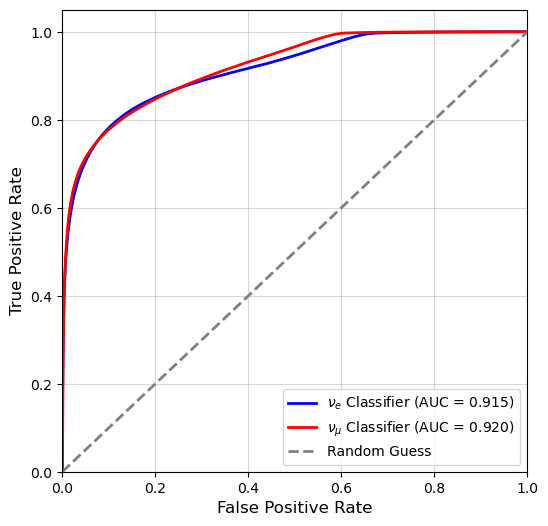

In [10]:
from sklearn.metrics import roc_curve, auc


print("Loading data...")
with uproot.open(file_name) as f:
    tree = f['cafTree']
    all_branches = [PDG_BRANCH] + list(CVN_BRANCHES.values())
    data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

# Flatten 
df = pd.DataFrame()
for col in all_branches:
    df[col] = data[col].apply(lambda cell: (cell[0] if len(cell) > 0 else -999) if isinstance(cell, (list, np.ndarray)) else cell)
print("Data flattened.")


print("Calculating ROC curves...")

valid_nue_mask = (df[CVN_BRANCHES['nue']] != -999) & (df[CVN_BRANCHES['nue']].notna())

y_true_nue = (df.loc[valid_nue_mask, PDG_BRANCH].abs() == 12).astype(int)
y_score_nue = df.loc[valid_nue_mask, CVN_BRANCHES['nue']]

# Calculate ROC and AUC for Nue
fpr_nue, tpr_nue, _ = roc_curve(y_true_nue, y_score_nue)
auc_nue = auc(fpr_nue, tpr_nue)

valid_numu_mask = (df[CVN_BRANCHES['numu']] != -999) & (df[CVN_BRANCHES['numu']].notna())

y_true_numu = (df.loc[valid_numu_mask, PDG_BRANCH].abs() == 14).astype(int)
y_score_numu = df.loc[valid_numu_mask, CVN_BRANCHES['numu']]

# Calculate ROC and AUC for Numu
fpr_numu, tpr_numu, _ = roc_curve(y_true_numu, y_score_numu)
auc_numu = auc(fpr_numu, tpr_numu)

plt.rcParams.update({
	"font.size": 11,
	"axes.labelsize": 12,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.titlesize": 12
})

plt.figure(figsize=(6,6))

plt.plot(fpr_nue, tpr_nue, color='blue', lw=2, 
            label=r'$\nu_e$ Classifier (AUC = {:.3f})'.format(auc_nue))

plt.plot(fpr_numu, tpr_numu, color='red', lw=2, 
            label=r'$\nu_\mu$ Classifier (AUC = {:.3f})'.format(auc_numu))

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.5)

print("Displaying plot...")
plt.savefig(os.path.join(save_dir, "cvn_roc.pdf"), bbox_inches="tight")
plt.show()


Loading data...
Data loaded successfully.
Data flattened.
Calculating true direction unit vector...
Plotting True Direction components...


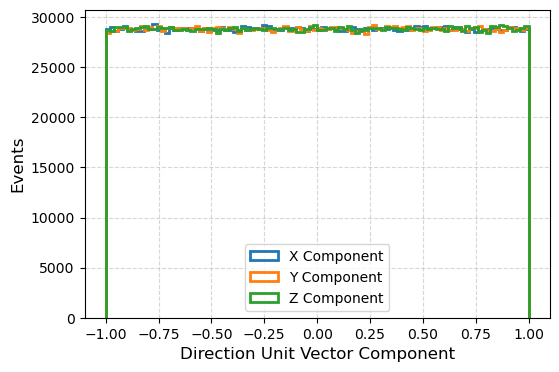

Plotting Longest Track Resolution...


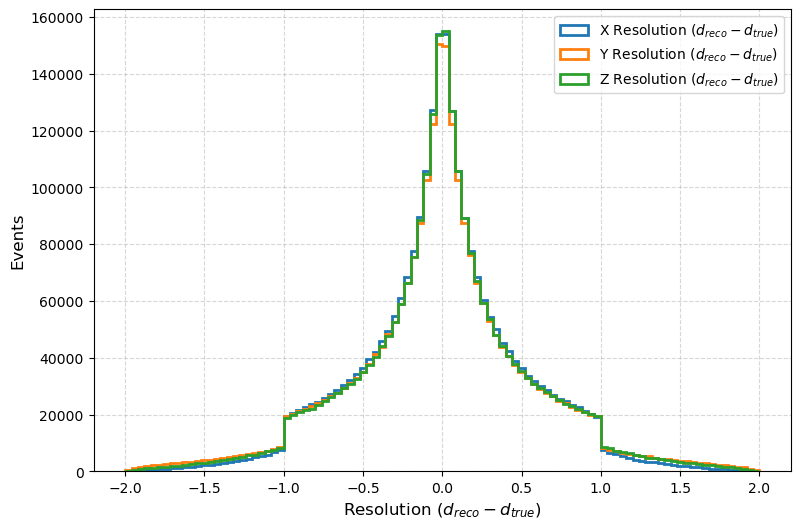

Plotting Longest Shower Resolution...


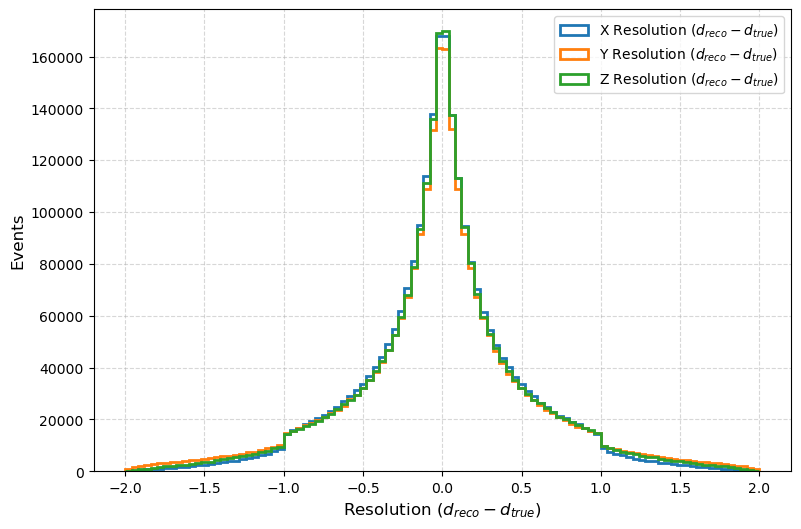

In [19]:
TRUE_MOM_BRANCHES = {
    'x': 'rec/mc/mc.nu/mc.nu.momentum.x',
    'y': 'rec/mc/mc.nu/mc.nu.momentum.y',
    'z': 'rec/mc/mc.nu/mc.nu.momentum.z'
}

# Reco longest track
RECO_TRK_BRANCHES = {
    'x': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.lngtrk.x',
    'y': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.lngtrk.y',
    'z': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.lngtrk.z'
}

# Reco longest shower
RECO_SHW_BRANCHES = {
    'x': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.heshw.x',
    'y': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.heshw.y',
    'z': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.heshw.z'
}

plt.rcParams.update({
	"font.size": 11,
	"axes.labelsize": 12,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.titlesize": 12
})

print("Loading data...")
with uproot.open(file_name) as f:
    tree = f['cafTree']
    
    all_branches = list(TRUE_MOM_BRANCHES.values()) + \
                    list(RECO_TRK_BRANCHES.values()) + \
                    list(RECO_SHW_BRANCHES.values())
                    
    data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

# Flatten 
df = pd.DataFrame()
for col in all_branches:
    df[col] = data[col].apply(lambda cell: (cell[0] if len(cell) > 0 else -999) if isinstance(cell, (list, np.ndarray)) else cell)
print("Data flattened.")

print("Calculating true direction unit vector...")
px = df[TRUE_MOM_BRANCHES['x']]
py = df[TRUE_MOM_BRANCHES['y']]
pz = df[TRUE_MOM_BRANCHES['z']]

p_mag = np.sqrt(px**2 + py**2 + pz**2)

p_mag_nozero = p_mag.replace(0, np.nan)

df['true_dir_x'] = px / p_mag_nozero
df['true_dir_y'] = py / p_mag_nozero
df['true_dir_z'] = pz / p_mag_nozero

valid_true_mask = df['true_dir_x'].notna()

print("Plotting True Direction components...")
plt.figure(figsize=(6, 4))
bins_dir = np.linspace(-1, 1, 101)

plt.hist(df.loc[valid_true_mask, 'true_dir_x'], bins=bins_dir, histtype='step', lw=2, label='X Component')
plt.hist(df.loc[valid_true_mask, 'true_dir_y'], bins=bins_dir, histtype='step', lw=2, label='Y Component')
plt.hist(df.loc[valid_true_mask, 'true_dir_z'], bins=bins_dir, histtype='step', lw=2, label='Z Component')

plt.xlabel('Direction Unit Vector Component')
plt.ylabel('Events')
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')
plt.savefig(os.path.join(save_dir, "true_direction_components.pdf"), bbox_inches="tight")
plt.show()

print("Plotting Longest Track Resolution...")
plt.figure(figsize=(9, 6))
bins_res = np.linspace(-2, 2, 101) 

valid_trk_mask = (df[RECO_TRK_BRANCHES['x']] != -999) & \
                    (df[RECO_TRK_BRANCHES['x']].notna()) & \
                    valid_true_mask

# Calculate resolution
res_trk_x = df.loc[valid_trk_mask, RECO_TRK_BRANCHES['x']] - df.loc[valid_trk_mask, 'true_dir_x']
res_trk_y = df.loc[valid_trk_mask, RECO_TRK_BRANCHES['y']] - df.loc[valid_trk_mask, 'true_dir_y']
res_trk_z = df.loc[valid_trk_mask, RECO_TRK_BRANCHES['z']] - df.loc[valid_trk_mask, 'true_dir_z']

plt.hist(res_trk_x, bins=bins_res, histtype='step', lw=2, label='X Resolution ($d_{reco} - d_{true}$)')
plt.hist(res_trk_y, bins=bins_res, histtype='step', lw=2, label='Y Resolution ($d_{reco} - d_{true}$)')
plt.hist(res_trk_z, bins=bins_res, histtype='step', lw=2, label='Z Resolution ($d_{reco} - d_{true}$)')

# longest track direction res
plt.xlabel(r'Resolution ($d_{reco} - d_{true}$)')
plt.ylabel('Events')
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')
plt.savefig(os.path.join(save_dir, "track_direction_resolution.pdf"), bbox_inches="tight")
plt.show()

# Longest Shower Resolution
print("Plotting Longest Shower Resolution...")
plt.figure(figsize=(9, 6))

valid_shw_mask = (df[RECO_SHW_BRANCHES['x']] != -999) & \
                    (df[RECO_SHW_BRANCHES['x']].notna()) & \
                    valid_true_mask

res_shw_x = df.loc[valid_shw_mask, RECO_SHW_BRANCHES['x']] - df.loc[valid_shw_mask, 'true_dir_x']
res_shw_y = df.loc[valid_shw_mask, RECO_SHW_BRANCHES['y']] - df.loc[valid_shw_mask, 'true_dir_y']
res_shw_z = df.loc[valid_shw_mask, RECO_SHW_BRANCHES['z']] - df.loc[valid_shw_mask, 'true_dir_z']

plt.hist(res_shw_x, bins=bins_res, histtype='step', lw=2, label='X Resolution ($d_{reco} - d_{true}$)')
plt.hist(res_shw_y, bins=bins_res, histtype='step', lw=2, label='Y Resolution ($d_{reco} - d_{true}$)')
plt.hist(res_shw_z, bins=bins_res, histtype='step', lw=2, label='Z Resolution ($d_{reco} - d_{true}$)')

# longest shower direction res
plt.xlabel(r'Resolution ($d_{reco} - d_{true}$)')
plt.ylabel('Events')
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')
plt.savefig(os.path.join(save_dir, "shower_direction_resolution.pdf"), bbox_inches="tight")
plt.show()


<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\s'
<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2762374/3815651079.py:97: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_fit, p, 'k--', linewidth=2, label=f'$\mu={mu:.2f}$\n$\sigma={sigma:.2f}$')
/tmp/ipykernel_2762374/3815651079.py:97: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x_fit, p, 'k--', linewidth=2, label=f'$\mu={mu:.2f}$\n$\sigma={sigma:.2f}$')


Loading data...
Data loaded successfully.
Data flattened.
Calculating Vertex Resolutions...
Displaying plots...


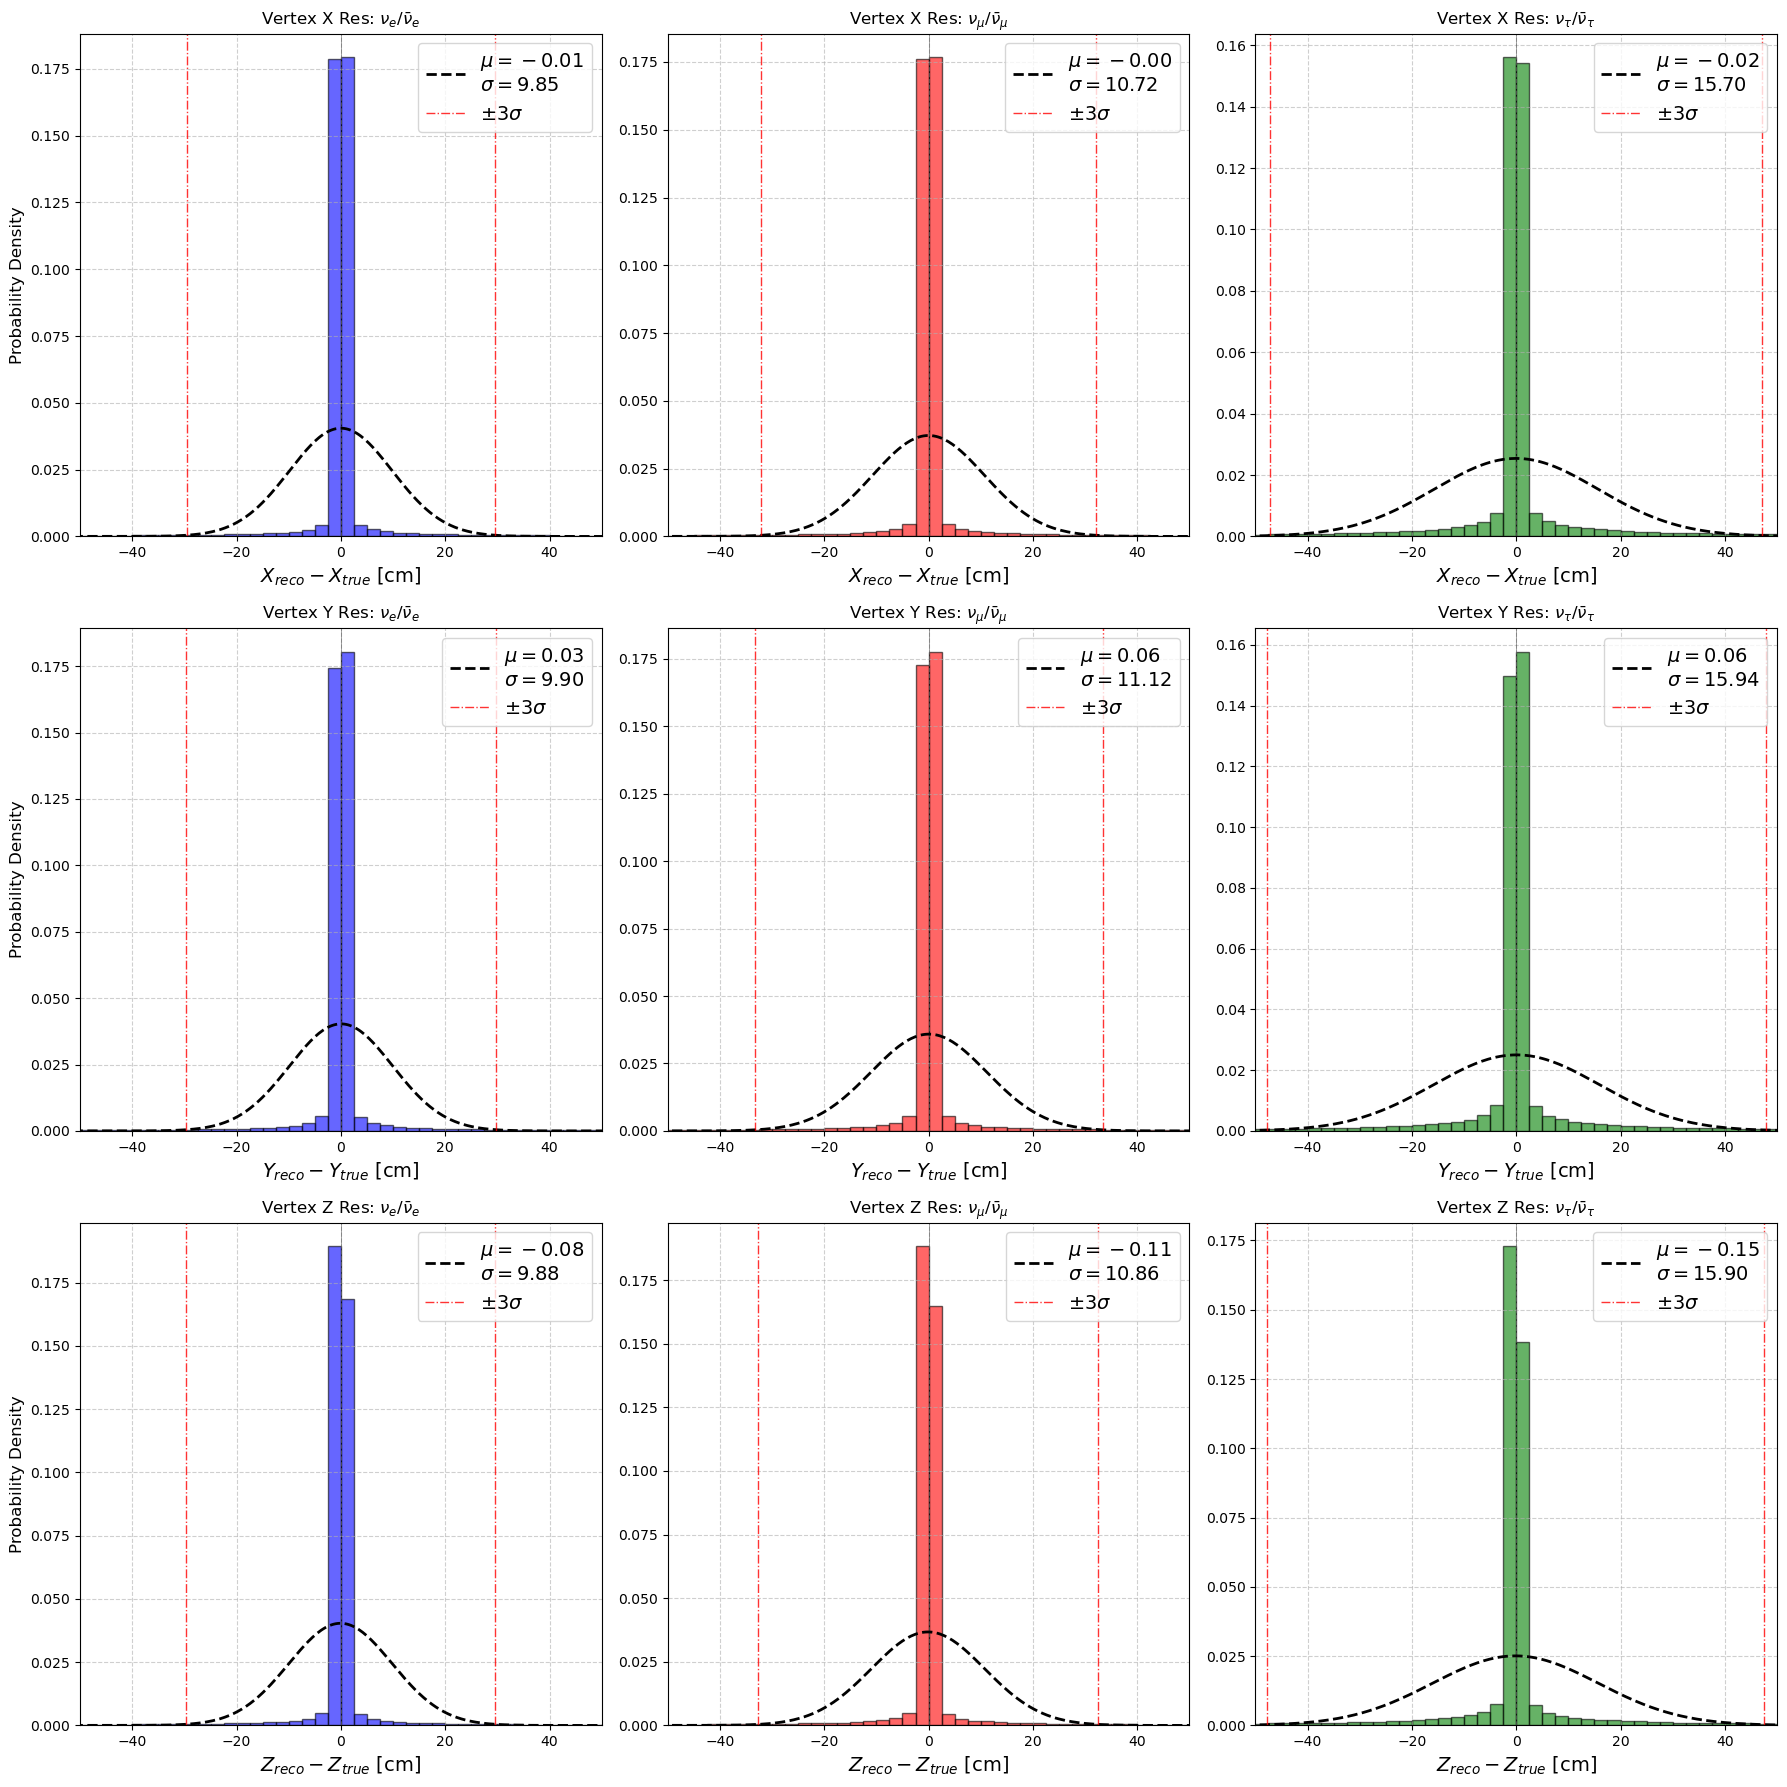

In [12]:
from scipy.stats import norm

TRUE_VTX_BRANCHES = {
	'x': 'rec/mc/mc.nu/mc.nu.vtx.x',
	'y': 'rec/mc/mc.nu/mc.nu.vtx.y',
	'z': 'rec/mc/mc.nu/mc.nu.vtx.z'
}
RECO_VTX_BRANCHES = {
	'x': 'rec/common/common.ixn.pandora/common.ixn.pandora.vtx.x',
	'y': 'rec/common/common.ixn.pandora/common.ixn.pandora.vtx.y',
	'z': 'rec/common/common.ixn.pandora/common.ixn.pandora.vtx.z'
}

plt.rcParams.update({
	"font.size": 11,
	"axes.labelsize": 12,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.titlesize": 12
})

print("Loading data...")
with uproot.open(file_name) as f:
	tree = f['cafTree']
	
	all_branches = [PDG_BRANCH] + \
					list(TRUE_VTX_BRANCHES.values()) + \
					list(RECO_VTX_BRANCHES.values())
					
	data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

# Flatten
df = pd.DataFrame()
for col in all_branches:
	df[col] = data[col].apply(lambda cell: (cell[0] if len(cell) > 0 else -999) if isinstance(cell, (list, np.ndarray)) else cell)
print("Data flattened.")

valid_mask = (df[PDG_BRANCH].notna())
for b in list(TRUE_VTX_BRANCHES.values()) + list(RECO_VTX_BRANCHES.values()):
	valid_mask &= (df[b] != -999) & (df[b].notna())

df = df[valid_mask].copy()

print("Calculating Vertex Resolutions...")
df['x_diff'] = df[RECO_VTX_BRANCHES['x']] - df[TRUE_VTX_BRANCHES['x']]
df['y_diff'] = df[RECO_VTX_BRANCHES['y']] - df[TRUE_VTX_BRANCHES['y']]
df['z_diff'] = df[RECO_VTX_BRANCHES['z']] - df[TRUE_VTX_BRANCHES['z']]

flavor_masks = {
	r'$\nu_e / \bar{\nu}_e$': (df[PDG_BRANCH].abs() == 12),
	r'$\nu_\mu / \bar{\nu}_\mu$': (df[PDG_BRANCH].abs() == 14),
	r'$\nu_\tau / \bar{\nu}_\tau$': (df[PDG_BRANCH].abs() == 16)
}

colors = ['blue', 'red', 'green']
variables = ['x', 'y', 'z']

fig, axes = plt.subplots(3, 3, figsize=(18, 18), sharey=False)

bins = 80
plot_range = (-100, 100)

for i, var in enumerate(variables):
	diff_col = f'{var}_diff'
	var_upper = var.upper()

	for j, ((label, mask), color) in enumerate(zip(flavor_masks.items(), colors)):
		ax = axes[i, j]
		
		data_flavor = df.loc[mask, diff_col]
		data_in_range = data_flavor[(data_flavor >= plot_range[0]) & (data_flavor <= plot_range[1])]

		if len(data_in_range) == 0:
			ax.set_title(f"Vertex {var_upper} Res: {label}\n(No Data)")
			ax.set_xlabel(fr'${var_upper}_{{reco}} - {var_upper}_{{true}}$ [cm]')
			if j == 0:
				ax.set_ylabel('Probability Density', fontsize = 14)
			ax.grid(True, linestyle='--', alpha=0.6)
			continue

		counts, bin_edges, _ = ax.hist(
			data_in_range,
			bins=bins,
			range=plot_range,
			color=color,
			alpha=0.6,
			edgecolor='black',
			density=True
		)

		mu, sigma = norm.fit(data_in_range)

		x_fit = np.linspace(plot_range[0], plot_range[1], 500)
		p = norm.pdf(x_fit, mu, sigma)
		ax.plot(x_fit, p, 'k--', linewidth=2, label=f'$\mu={mu:.2f}$\n$\sigma={sigma:.2f}$')

		x_3sig_left = mu - 3*sigma
		x_3sig_right = mu + 3*sigma

		y_3sig_left = norm.pdf(x_3sig_left, mu, sigma)
		y_3sig_right = norm.pdf(x_3sig_right, mu, sigma)

		ax.axvline(x_3sig_left, color='red', linestyle='-.', linewidth=1, alpha=0.8, label=r'$\pm 3\sigma$')
		ax.axvline(x_3sig_right, color='red', linestyle='-.', linewidth=1, alpha=0.8)


		ax.set_title(f"Vertex {var_upper} Res: {label}")
		ax.set_xlabel(fr'${var_upper}_{{reco}} - {var_upper}_{{true}}$ [cm]', fontsize=14)
		ax.set_xlim(-50,50)
		
		if j == 0:
			ax.set_ylabel('Probability Density')

		ax.legend(loc='upper right', frameon=True, fontsize=14)
		ax.grid(True, linestyle='--', alpha=0.6)
		ax.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

print("Displaying plots...")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "vertex_resolution_by_flavor.pdf"), bbox_inches="tight")
plt.show()

Loading data...
Data loaded successfully.
Data flattened.
Calculating metrics for nue...
Calculating metrics for numu...
Displaying plots...


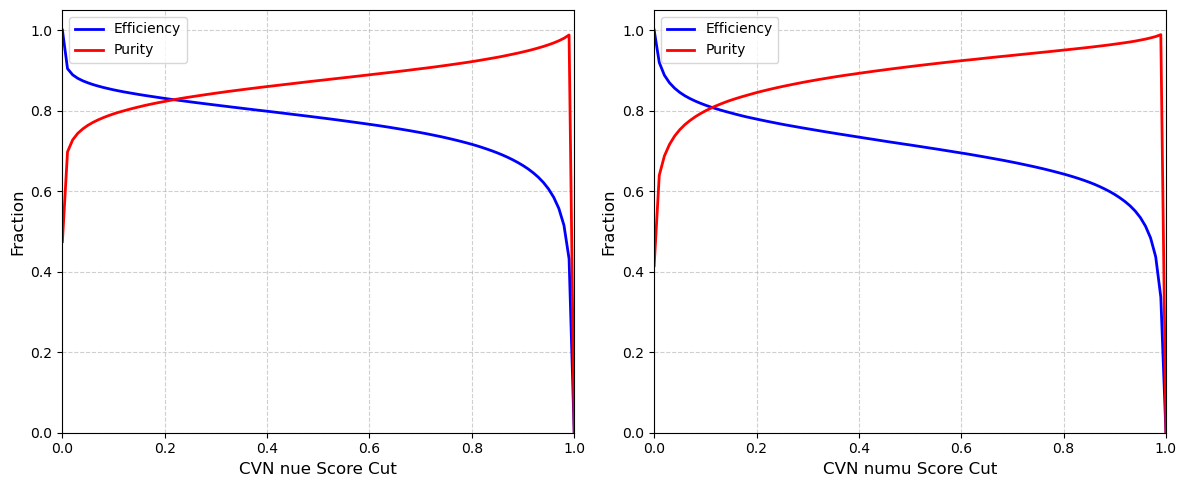

In [20]:
CVN_BRANCHES = {
    'nue': 'rec/common/common.ixn.pandora/common.ixn.pandora.nuhyp.cvn.nue',
    'numu': 'rec/common/common.ixn.pandora/common.ixn.pandora.nuhyp.cvn.numu'
}

SIGNAL_PDG = {
    'nue': 12,
    'numu': 14
}

#performance of both classifiers as function of cut value, with efficiency and purity curves on same plot

plt.rcParams.update({
	"font.size": 11,
	"axes.labelsize": 12,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.titlesize": 12
})

print("Loading data...")
with uproot.open(file_name) as f:
    tree = f['cafTree']
    all_branches = [PDG_BRANCH] + list(CVN_BRANCHES.values())
    data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

# Flatten 
df = pd.DataFrame()
for col in all_branches:
    df[col] = data[col].apply(lambda cell: (cell[0] if len(cell) > 0 else -999) if isinstance(cell, (list, np.ndarray)) else cell)
print("Data flattened.")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cuts = np.linspace(0.0, 1.0, 101)

for ax, (classifier_name, cvn_branch) in zip(axes, CVN_BRANCHES.items()):
    
    print(f"Calculating metrics for {classifier_name}...")
    
    valid_mask = (df[cvn_branch] != -999) & (df[cvn_branch].notna())
    
    # Define signal, bgnd
    signal_pdg_code = SIGNAL_PDG[classifier_name]
    is_signal = (df[PDG_BRANCH].abs() == signal_pdg_code)
    
    signal_scores = df.loc[valid_mask & is_signal, cvn_branch]
    bkg_scores = df.loc[valid_mask & ~is_signal, cvn_branch]
    
    total_signal_events = len(signal_scores)
    
    if total_signal_events == 0:
        print(f"No valid signal events found for {classifier_name}. Skipping.")
        ax.set_title(f"{classifier_name} (No Data)")
        continue

    efficiencies = []
    purities = []
    
    for cut in cuts:
        # Tp: Signal events above cut
        tp = np.sum(signal_scores >= cut)
        
        # Fp: Bg events above cut
        fp = np.sum(bkg_scores >= cut)
        
        # Efficiency = TP / total signal
        eff = tp / total_signal_events
        
        # Purity = TP / (TP + FP)
        if (tp + fp) > 0:
            pur = tp / (tp + fp)
        else:
            pur = 0.0 
            
        efficiencies.append(eff)
        purities.append(pur)

    # Plot
    ax.plot(cuts, efficiencies, label='Efficiency', color='blue', lw=2)
    ax.plot(cuts, purities, label='Purity', color='red', lw=2)
    
    ax.set_xlabel(f'CVN {classifier_name} Score Cut')
    ax.set_ylabel('Fraction')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
print("Displaying plots...")
plt.savefig(os.path.join(save_dir, "cvn_efficiency_purity.pdf"), bbox_inches="tight")
plt.show()


Loading data...
Data loaded successfully.
Data flattened.
Plotting True Energy by Flavor...


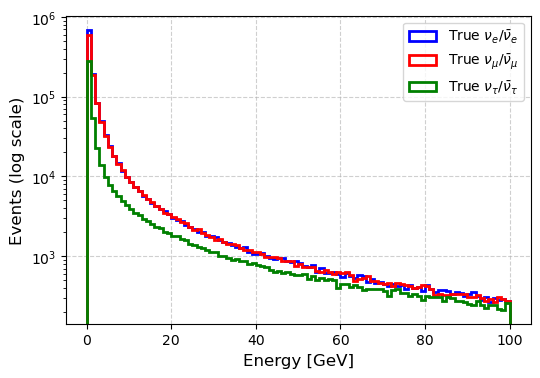

In [14]:
TRUE_E_BRANCH = 'rec/mc/mc.nu/mc.nu.E'

# True Neutrino Energy Distribution by Flavor
plt.rcParams.update({
	"font.size": 11,
	"axes.labelsize": 12,
	"xtick.labelsize": 10,
	"ytick.labelsize": 10,
	"legend.fontsize": 10,
	"axes.titlesize": 12
})


print("Loading data...")
with uproot.open(file_name) as f:
    tree = f['cafTree']
    
    all_branches = [TRUE_E_BRANCH, PDG_BRANCH]
                    
    data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

# Flatten 
df = pd.DataFrame()
for col in all_branches:
    df[col] = data[col].apply(lambda cell: (cell[0] if len(cell) > 0 else -999) if isinstance(cell, (list, np.ndarray)) else cell)
print("Data flattened.")

valid_mask = (df[TRUE_E_BRANCH] != -999) & (df[PDG_BRANCH] != -999)
df = df[valid_mask].copy()

is_nue = (df[PDG_BRANCH].abs() == 12)
is_numu = (df[PDG_BRANCH].abs() == 14)
is_nutau = (df[PDG_BRANCH].abs() == 16)

print("Plotting True Energy by Flavor...")
plt.figure(figsize=(6, 4))

bins = 100
plot_range = (0, 100) # GeV

nue_energy = df.loc[is_nue, TRUE_E_BRANCH]
numu_energy = df.loc[is_numu, TRUE_E_BRANCH]
nutau_energy = df.loc[is_nutau, TRUE_E_BRANCH]

plt.hist(nue_energy, bins=bins, range=plot_range, 
            label=r'True $\nu_e / \bar{\nu}_e$', histtype='step', lw=2, color='blue')
            
plt.hist(numu_energy, bins=bins, range=plot_range, 
            label=r'True $\nu_\mu / \bar{\nu}_\mu$', histtype='step', lw=2, color='red')
            
plt.hist(nutau_energy, bins=bins, range=plot_range, 
            label=r'True $\nu_\tau / \bar{\nu}_\tau$', histtype='step', lw=2, color='green')

plt.yscale('log') 
plt.xlabel('Energy [GeV]')
plt.ylabel('Events (log scale)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(os.path.join(save_dir, "true_energy_by_flavor.pdf"), bbox_inches="tight")
plt.show() 


Loading data...
Data loaded successfully.
Data flattened.
Plotting Longest Track direction by flavor...


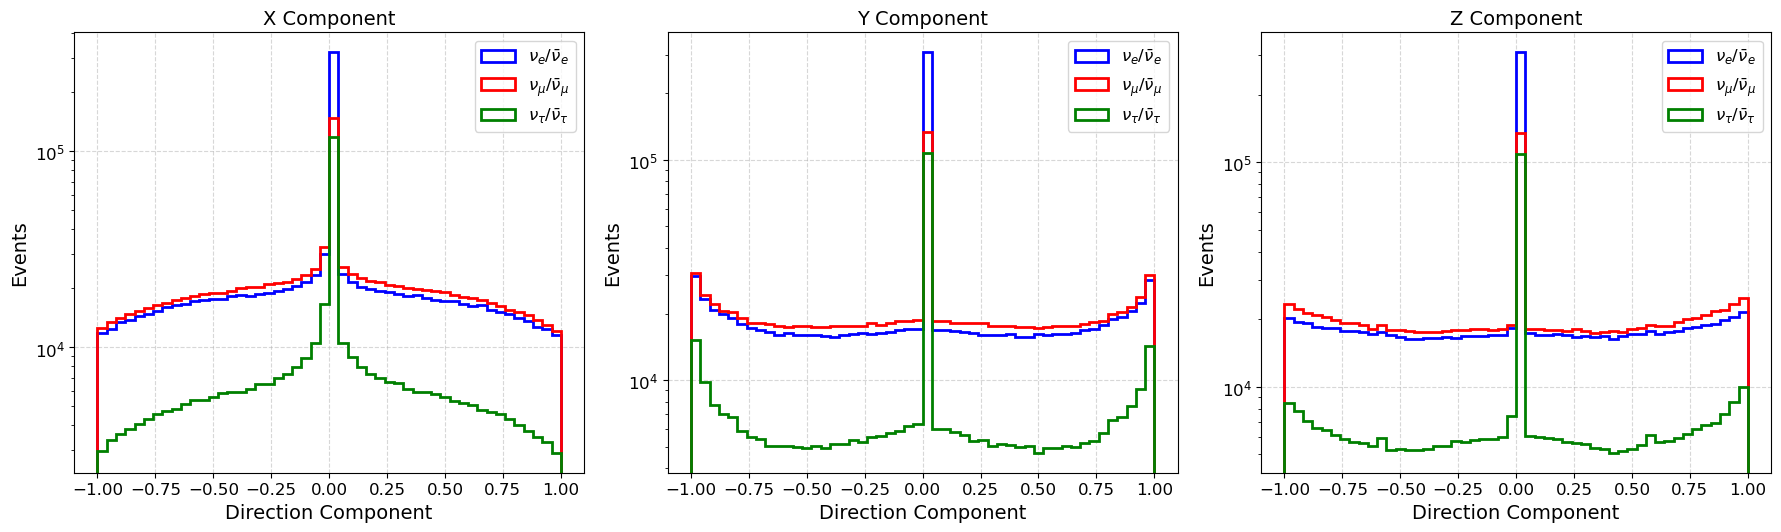

Plotting Longest Shower direction by flavor...


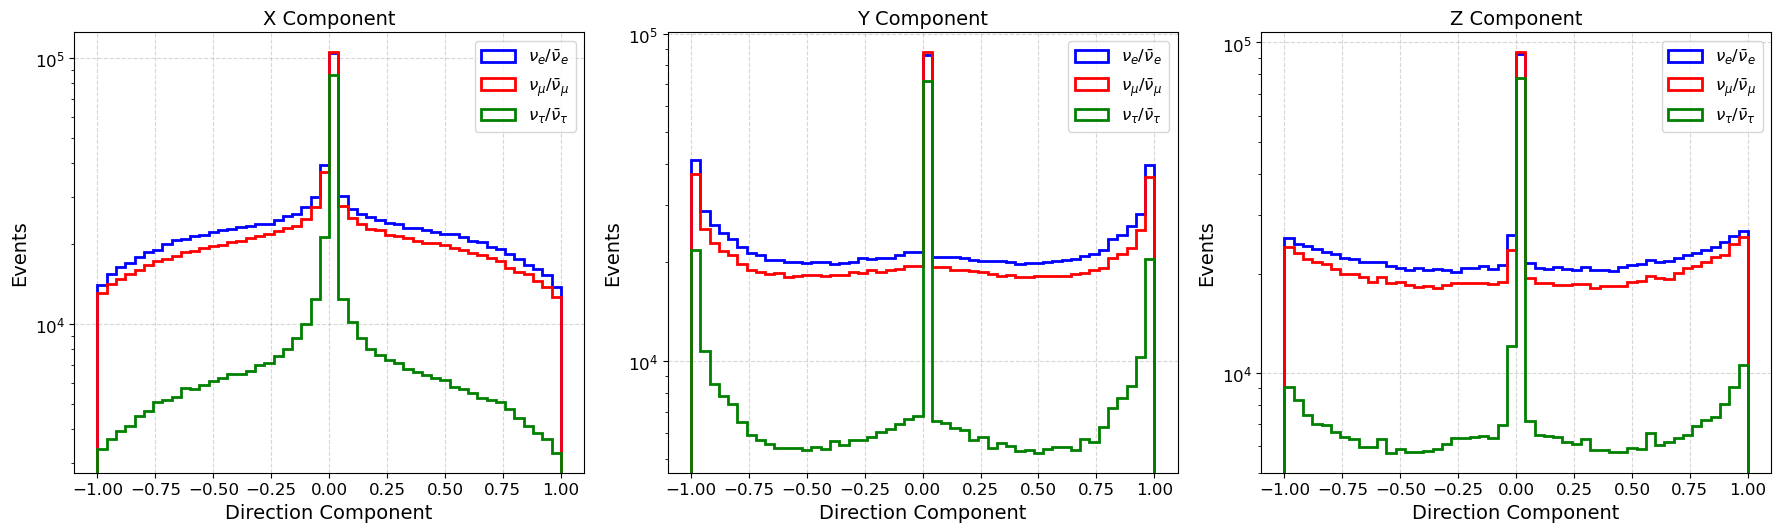

In [21]:

# Reco longest track
RECO_TRK_BRANCHES = {
    'x': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.lngtrk.x',
    'y': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.lngtrk.y',
    'z': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.lngtrk.z'
}

# Reco longest shower
RECO_SHW_BRANCHES = {
    'x': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.heshw.x',
    'y': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.heshw.y',
    'z': 'rec/common/common.ixn.pandora/common.ixn.pandora.dir.heshw.z'
}

plt.rcParams.update({
	"font.size": 13,
	"axes.labelsize": 14,
	"xtick.labelsize": 12,
	"ytick.labelsize": 12,
	"legend.fontsize": 12,
	"axes.titlesize": 14
})

print("Loading data...")
with uproot.open(file_name) as f:
    tree = f['cafTree']
    
    all_branches = [PDG_BRANCH] + \
                    list(RECO_TRK_BRANCHES.values()) + \
                    list(RECO_SHW_BRANCHES.values())
                    
    data = tree.arrays(all_branches, library='pd')
print("Data loaded successfully.")

# Flatten 
df = pd.DataFrame()
for col in all_branches:
    df[col] = data[col].apply(lambda cell: (cell[0] if len(cell) > 0 else -999) if isinstance(cell, (list, np.ndarray)) else cell)
print("Data flattened.")

valid_mask = (df[PDG_BRANCH] != -999)
for b in list(RECO_TRK_BRANCHES.values()) + list(RECO_SHW_BRANCHES.values()):
    valid_mask &= (df[b] != -999) & (df[b].notna())

df = df[valid_mask].copy()

is_nue = (df[PDG_BRANCH].abs() == 12)
is_numu = (df[PDG_BRANCH].abs() == 14)
is_nutau = (df[PDG_BRANCH].abs() == 16)

flavor_data = {
    r'$\nu_e / \bar{\nu}_e$': df[is_nue],
    r'$\nu_\mu / \bar{\nu}_\mu$': df[is_numu],
    r'$\nu_\tau / \bar{\nu}_\tau$': df[is_nutau]
}

colors = ['blue', 'red', 'green']

print("Plotting Longest Track direction by flavor...")
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))

bins_dir = np.linspace(-1, 1, 51)

for ax, comp in zip(axes1, ['x', 'y', 'z']):
    branch = RECO_TRK_BRANCHES[comp]
    
    for (label, data), color in zip(flavor_data.items(), colors):
        ax.hist(data[branch], bins=bins_dir, histtype='step', lw=2, 
                label=label, color=color)
    
    ax.set_title(f'{comp.upper()} Component')
    ax.set_xlabel('Direction Component')
    ax.set_ylabel('Events')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(save_dir, "track_reco_direction_by_flavor.pdf"), bbox_inches="tight")
plt.show()

print("Plotting Longest Shower direction by flavor...")
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))

for ax, comp in zip(axes2, ['x', 'y', 'z']):
    branch = RECO_SHW_BRANCHES[comp]
    
    for (label, data), color in zip(flavor_data.items(), colors):
        ax.hist(data[branch], bins=bins_dir, histtype='step', lw=2, 
                label=label, color=color)
    
    ax.set_title(f'{comp.upper()} Component')
    ax.set_xlabel('Direction Component')
    ax.set_ylabel('Events')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.5, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(save_dir, "shower_reco_direction_by_flavor.pdf"), bbox_inches="tight")
plt.show()
